# 1d Filter Implementation
A kalman filter keeps track of the estimated state of the system and the variance or uncertainty of the estimate. <a href="https://en.wikipedia.org/wiki/Kalman_filter">(wikipedia)</a>

We have a system motion model w/ constant velocity $s$, moving along a 1d line.
$$
x_{t} = x_{t-1} + s + r
$$
with gaussian movement noise $r$
$$
r \sim N(0, \sigma_{r})
$$

Predictions then update through the recursive motion equations
$$
\hat{x} \rightarrow \hat{x} + s
$$
Variance compounds as we draw more measurements and have more noise
$$
\sigma^{2} \rightarrow \sigma^{2} + \sigma_{r}^{2}
$$

We also must take into account that we have noise in the measurement apparatus. Therefore we have our measurement z which is the ground truth position with gaussian noise added
$$
z = x + q
$$

$$
q \sim N(0, \sigma_{q})
$$

From a long draw out derivation, we know that our predictions of the mean and variance must update like so
$$
\hat{x} = \hat{x} + K(z - \hat{x})
$$

$$
\sigma^{2} = \sigma^{2} - K \sigma^{2}
$$

And here, we know that K is our "kalman gain"
$$
K = \frac{\sigma^{2}}{\sigma^{2} + \sigma^2_{q}}
$$

### Real Trajectory Simulation
First, we should just simulate the real trajectory

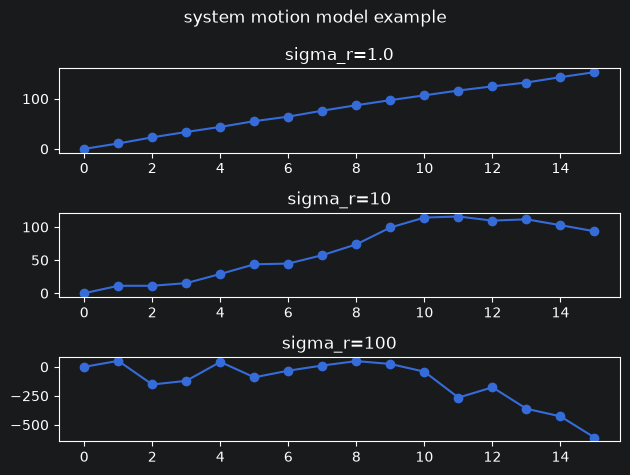

In [21]:
import numpy as np
from matplotlib import pyplot as plt
plt.close('all')

def system_step(n, x_vec, s, sigma_r):
    """
    Recursively iterate the system state
    :param n: number of time steps
    :param x_vec: stored trajectory
    :param s: constant velocity
    :param v: system noise standard deviation
    """
    if n <= 0:
        return x_vec
    noise = np.random.normal(0, sigma_r)
    x = x_vec[-1] + s + noise
    x_vec.append(x)
    return system_step(n - 1, x_vec, s, sigma_r)

fig, axs = plt.subplots(3)
s = 10.0
for i,sigma_r in enumerate([1.0, 10, 100]):
    x_vec = [0]
    real_traj = system_step(15, x_vec, s, sigma_r)
    axs[i].plot(real_traj, linestyle='-', marker='o')
    axs[i].set_title(f"sigma_r={sigma_r}")
fig.suptitle("system motion model example")
plt.tight_layout()

## Add measurement noise

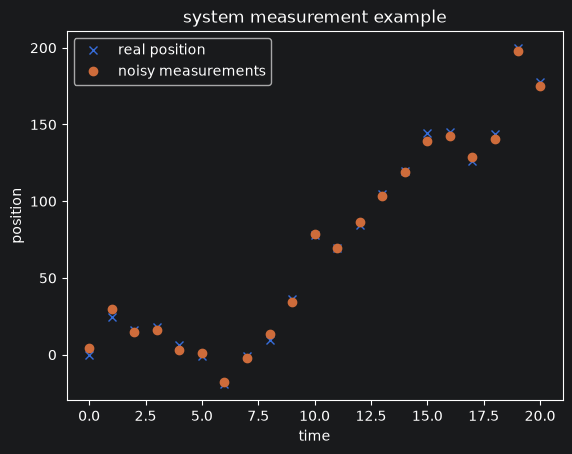

In [24]:
def make_measurements(real_traj, sigma_q):
    m_noise = np.random.normal(0, sigma_q, len(real_traj))
    noisy_traj = [
        t + m for t,m in zip(real_traj, m_noise)
    ]
    return noisy_traj

s = 10.0
sigma_r = 20.0
x_vec = [0]
real_traj = system_step(20, x_vec, s, sigma_r)
sigma_q = 4.0
noisy_traj = make_measurements(real_traj, sigma_q)
plt.plot(real_traj, linestyle='', marker='x', label="real position")
plt.plot(noisy_traj, linestyle='', marker='o', label="noisy measurements")
plt.title("system measurement example")
plt.xlabel("time")
plt.ylabel("position")
plt.legend()